# Supply Chain Risk Detection System
This notebook implements an end-to-end anomaly detection and risk classification pipeline for logistics data. We use Isolation Forest for unsupervised anomaly detection and a Random Forest classifier for risk scoring.

# Step 1 - Setup and data loading

In [1]:
 # Install dependencies (run once in Colab)
!pip install pandas numpy scikit-learn matplotlib seaborn shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Synthetic logistics dataset (replace with real CSV in production)
# Columns mirror standard freight datasets: SCMS, UN OCHA logistics, etc.

n = 2000
suppliers = ['Alpha Freight', 'Beta Logistics', 'Gamma Cargo', 'Delta Express', 'Epsilon Routes']
routes    = ['Asia-EU', 'US-LATAM', 'EU-MENA', 'Intra-Asia', 'US-EU']

df = pd.DataFrame({
    'shipment_id':      [f'SHP-{i:04d}' for i in range(n)],
    'supplier':         np.random.choice(suppliers, n),
    'route':            np.random.choice(routes, n),
    'planned_days':     np.random.randint(5, 30, n),
    'actual_days':      np.random.randint(5, 45, n),
    'cargo_value_usd':  np.random.uniform(5000, 500000, n),
    'freight_cost_usd': np.random.uniform(500, 50000, n),
    'customs_hold_days':np.where(np.random.rand(n) < 0.15, np.random.randint(1, 20, n), 0),
    'num_transfers':    np.random.randint(0, 5, n),
    'weather_severity': np.random.uniform(0, 10, n),
    'carrier_rating':   np.random.uniform(1, 5, n),
    'port_congestion':  np.random.uniform(0, 1, n),
})

print(f"Dataset loaded: {df.shape[0]} shipments, {df.shape[1]} features")
df.head()

Dataset loaded: 2000 shipments, 12 features


,shipment_id,supplier,route,planned_days,actual_days,cargo_value_usd,freight_cost_usd,customs_hold_days,num_transfers,weather_severity,carrier_rating,port_congestion
0,SHP-0000,Delta Express,Intra-Asia,28,23,229367.393074,37334.270943,0,2,9.181918,1.620374,0.398361
1,SHP-0001,Epsilon Routes,EU-MENA,25,22,427322.027068,40386.746865,11,2,3.813358,2.071986,0.821588
2,SHP-0002,Gamma Cargo,US-LATAM,6,16,292753.904764,13933.715318,0,3,7.651902,2.572708,0.844056
3,SHP-0003,Epsilon Routes,Asia-EU,15,32,44070.278244,23844.624252,17,1,5.976870,2.119718,0.736980
4,SHP-0004,Epsilon Routes,US-EU,10,32,99877.302821,35693.903102,0,2,9.270121,1.911241,0.896878


# Step 2 - Feature engineering

In [3]:
# Derived features capturing delay dynamics and cost efficiency

df['delay_days']           = df['actual_days'] - df['planned_days']
df['delay_ratio']          = df['delay_days'] / df['planned_days']
df['total_hold_days']      = df['customs_hold_days'] + df['delay_days'].clip(0)
df['cost_per_day']         = df['freight_cost_usd'] / df['actual_days'].clip(1)
df['value_at_risk']        = df['cargo_value_usd'] * df['delay_ratio'].clip(0)
df['complexity_score']     = df['num_transfers'] * df['port_congestion']
df['environmental_impact'] = df['weather_severity'] * df['port_congestion']

# Label encode categorical columns
le = LabelEncoder()
df['supplier_enc'] = le.fit_transform(df['supplier'])
df['route_enc']    = le.fit_transform(df['route'])

# Realistic risk label: weighted score across multiple signals
df['risk_score'] = (
    0.40 * (df['delay_ratio'].clip(0, 2) / 2) +
    0.25 * (df['customs_hold_days'] / df['customs_hold_days'].max()) +
    0.20 * df['port_congestion'] +
    0.15 * (1 - df['carrier_rating'] / 5)
)

# Add noise so the boundary is not perfectly learnable
noise = np.random.normal(0, 0.05, len(df))
df['risk_label'] = (df['risk_score'] + noise > 0.35).astype(int)

print(f"High-risk shipments: {df['risk_label'].sum()} ({df['risk_label'].mean():.1%})")
print(f"New features created: {['delay_ratio','total_hold_days','cost_per_day','value_at_risk','complexity_score']}")

High-risk shipments: 764 (38.2%)
New features created: ['delay_ratio', 'total_hold_days', 'cost_per_day', 'value_at_risk', 'complexity_score']


# Step 3 - Anomaly detection (Isolation Forest)

In [4]:
anomaly_features = [
    'delay_ratio', 'total_hold_days', 'cost_per_day',
    'complexity_score', 'environmental_impact',
    'carrier_rating', 'port_congestion', 'num_transfers'
]

scaler = StandardScaler()
X_anom = scaler.fit_transform(df[anomaly_features])

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.08,  # expect ~8% anomalous shipments
    random_state=42,
    max_samples='auto'
)

df['anomaly_score'] = iso_forest.fit_predict(X_anom)
df['anomaly_raw']  = iso_forest.score_samples(X_anom)
df['is_anomaly']   = (df['anomaly_score'] == -1)

print(f"Anomalies detected: {df['is_anomaly'].sum()} ({df['is_anomaly'].mean():.1%} of shipments)")
print(df.groupby('is_anomaly')[['delay_days', 'customs_hold_days', 'value_at_risk']].mean().round(2))

Anomalies detected: 160 (8.0% of shipments)
            delay_days  customs_hold_days  value_at_risk
is_anomaly                                              
False             6.68               1.50      198614.08
True              9.77               2.78      546491.36


In [5]:
clf_features = [
    'delay_ratio', 'total_hold_days', 'cost_per_day',
    'complexity_score', 'environmental_impact',
    'carrier_rating', 'port_congestion', 'num_transfers',
    'value_at_risk', 'supplier_enc', 'route_enc'
    # delay_days intentionally excluded — it leaked the old label
]

X = df[clf_features]
y = df['risk_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Class balance (train): {y_train.mean():.1%} high-risk")

Train: (1600, 11), Test: (400, 11)
Class balance (train): 38.2% high-risk


# Step 4 - Risk classification (Random Forest)

In [6]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,           # reduced from 8 to prevent overfitting
    min_samples_leaf=15,   # stops the model memorizing small clusters
    max_features='sqrt',   # standard best practice for RF classifiers
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

df['risk_prob'] = rf.predict_proba(X)[:, 1]
df['risk_tier'] = pd.cut(
    df['risk_prob'],
    bins=[0, 0.35, 0.65, 1.0],
    labels=['Low', 'Medium', 'High']
)
print('Model trained. Risk tier distribution:')
print(df['risk_tier'].value_counts())

Model trained. Risk tier distribution:
risk_tier
Low       1008
High       660
Medium     332
Name: count, dtype: int64


# Step 5 - Model evaluation

In [7]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))

              precision    recall  f1-score   support

    Low Risk       0.95      0.87      0.91       247
   High Risk       0.82      0.92      0.87       153

    accuracy                           0.89       400
   macro avg       0.88      0.90      0.89       400
weighted avg       0.90      0.89      0.89       400



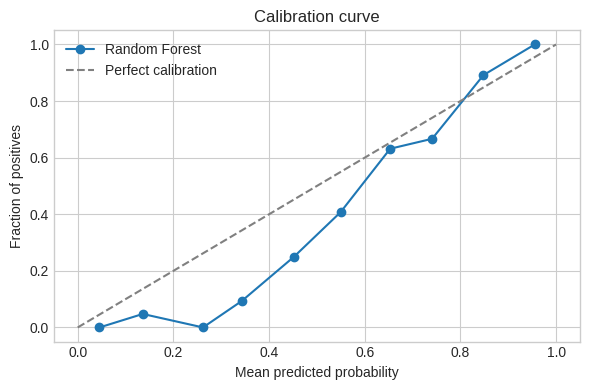

In [8]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, rf.predict_proba(X_test)[:, 1], n_bins=10)

plt.figure(figsize=(6, 4))
plt.plot(prob_pred, prob_true, marker='o', label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration curve')
plt.legend()
plt.tight_layout()
plt.show()

# Step 6 - SHAP explanation and top risky shipments

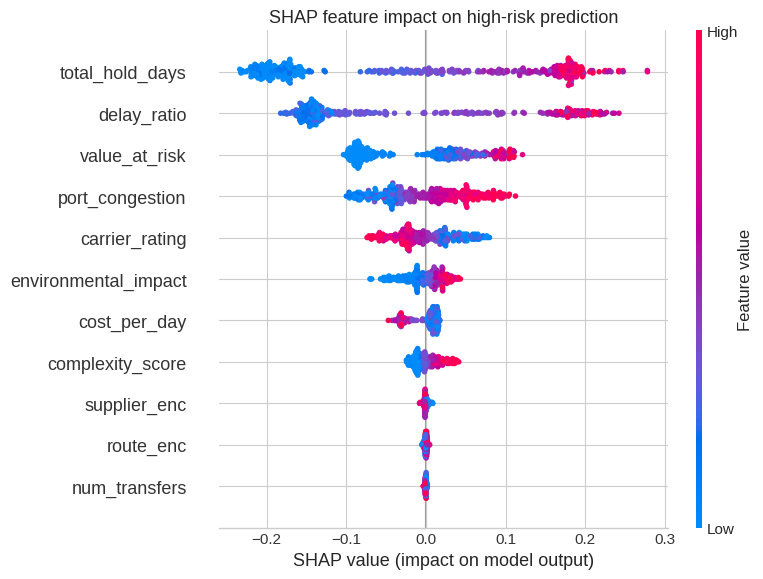

shipment_id       supplier      route  delay_days  risk_prob risk_tier  is_anomaly
   SHP-0986 Epsilon Routes    EU-MENA          33   0.991991      High        True
   SHP-0420 Beta Logistics Intra-Asia          27   0.991417      High        True
   SHP-1274    Gamma Cargo      US-EU          30   0.991327      High        True
   SHP-0885 Beta Logistics      US-EU          27   0.991167      High       False
   SHP-1097  Alpha Freight   US-LATAM          30   0.990766      High        True
   SHP-0909 Beta Logistics      US-EU          22   0.990719      High       False
   SHP-0897  Alpha Freight    EU-MENA          36   0.990591      High        True
   SHP-0266  Delta Express    EU-MENA          30   0.990554      High       False
   SHP-0677    Gamma Cargo      US-EU          30   0.990209      High       False
   SHP-0562 Epsilon Routes   US-LATAM          30   0.989973      High       False


In [9]:
# SHAP values for explainability
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# --- Fix: handle both old and new SHAP output shapes ---
if isinstance(shap_values, list):
    # Old SHAP (<= 0.41): list of [n_samples, n_features] arrays, one per class
    sv_highRisk = shap_values[1]
else:
    # New SHAP (>= 0.42): single 3D array [n_samples, n_features, n_classes]
    sv_highRisk = shap_values[:, :, 1]

# Summary plot
shap.summary_plot(sv_highRisk, X_test, feature_names=clf_features, show=False)
plt.title("SHAP feature impact on high-risk prediction", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)
plt.show()

# Risky shipment table: top 10 by risk probability
top_risk = df.nlargest(10, 'risk_prob')[[
    'shipment_id', 'supplier', 'route', 'delay_days',
    'risk_prob', 'risk_tier', 'is_anomaly'
]]
print(top_risk.to_string(index=False))

# Step 7 - Business insights and export

In [10]:
# Export risk-scored dataset for downstream use
output_cols = [
    'shipment_id', 'supplier', 'route', 'delay_days',
    'risk_prob', 'risk_tier', 'is_anomaly', 'value_at_risk'
]
df[output_cols].to_csv('supply_chain_risk_output.csv', index=False)
print("Risk-scored dataset saved to supply_chain_risk_output.csv")
print(f"Total value at risk (high-tier): ${df[df['risk_tier']=='High']['value_at_risk'].sum():,.0f}")

Risk-scored dataset saved to supply_chain_risk_output.csv
Total value at risk (high-tier): $368,497,522
